# Customer Churn Prediction - ML project personal project
    Customer churn is one of the most significant challenges faced by subscription-based businesses, directly impacting revenue, profitability, and long-term customer relationships. This project develops an end-to-end machine learning solution to predict customers who are likely to discontinue a service before churn occurs. The project covers the complete data science lifecycle, including business understanding, exploratory data analysis, data preprocessing, feature engineering, handling class imbalance, model development, evaluation, and deployment preparation. Multiple classification algorithms are trained and compared using performance metrics such as Recall, Precision, F1-score, ROC-AUC, and Confusion Matrix, with particular emphasis on Recall to minimize the cost of missing potential churners. The final model generates customer-level churn probabilities that enable businesses to prioritize high-risk customers for targeted retention campaigns. By identifying customers at risk early, organizations can reduce customer attrition, optimize marketing resources, and improve long-term profitability through data-driven decision-making.

In [52]:
# =================== Libraries Import ================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

In [53]:
RANDNOM_STATE = 42 # each run same result 

In [54]:
#=====================Load the data from github ====================
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
print(df.shape)

(7043, 21)


In [56]:
# ===== Data Types + Memory Audit =====
df.info(memory_usage='deep')
print('\nMemory: {:.2f} MB'.format(df.memory_usage(deep=True).sum() / 1024**2))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Detective 

In [57]:
# =========== Step 1: Missing Values (surface check ) =====
print("Missing Value:")
print(df.isnull().sum().sum(), 'Total')
#======== Step2 : TotalCharges ============
# Origanal numeric so i need convert to numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print("\n After convert : ", df['TotalCharges'].isnull().sum())

#Lets check the tenure(Subscription Duration)
print("\n Subscribtion(tenure) of missing rows ")
print(df.loc[df['TotalCharges'].isnull(), 'tenure'].values)

Missing Value:
0 Total

 After convert :  11

 Subscribtion(tenure) of missing rows 
[0 0 0 0 0 0 0 0 0 0 0]


Customers who have just subscribed have empty TotalCharges values because they have not been charged yet. Since the dataset stores these as empty strings ('') rather than null values, they appear as non-null during data inspection.

In [58]:
# ====================== Bussiness Logic impute ================================
#  The missing values in TotalCharges correspond to customers who have recently subscribed to the service.
# Since they have not completed their first billing cycle, their total charges are effectively zero.
# Therefore, we replace the missing values with 0.
df['TotalCharges'] = df['TotalCharges'].fillna(0) # tenure = 0 => no bill 

In [59]:
#================= Check the Duplicates ===============================
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())

# Let's make the SeniorCitizen column more readable by replacing 0 with No and 1 with Yes.
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

# Display all unique values for each categorical column (excluding customerID)
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
for col in cat_cols: print(f'{col:20s} -> {sorted(df[col].unique())}')

Duplicate rows: 0
Duplicate customerIDs: 0
gender               -> ['Female', 'Male']
SeniorCitizen        -> ['No', 'Yes']
Partner              -> ['No', 'Yes']
Dependents           -> ['No', 'Yes']
PhoneService         -> ['No', 'Yes']
MultipleLines        -> ['No', 'No phone service', 'Yes']
InternetService      -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity       -> ['No', 'No internet service', 'Yes']
OnlineBackup         -> ['No', 'No internet service', 'Yes']
DeviceProtection     -> ['No', 'No internet service', 'Yes']
TechSupport          -> ['No', 'No internet service', 'Yes']
StreamingTV          -> ['No', 'No internet service', 'Yes']
StreamingMovies      -> ['No', 'No internet service', 'Yes']
Contract             -> ['Month-to-month', 'One year', 'Two year']
PaperlessBilling     -> ['No', 'Yes']
PaymentMethod        -> ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
Churn                -> ['No', 'Yes']


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Outlier check (IQR Method ================

In [61]:
# ============ Outlier check (IQR Method) ===============
num_df = df.select_dtypes(include=[np.number])
print(num_df.describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


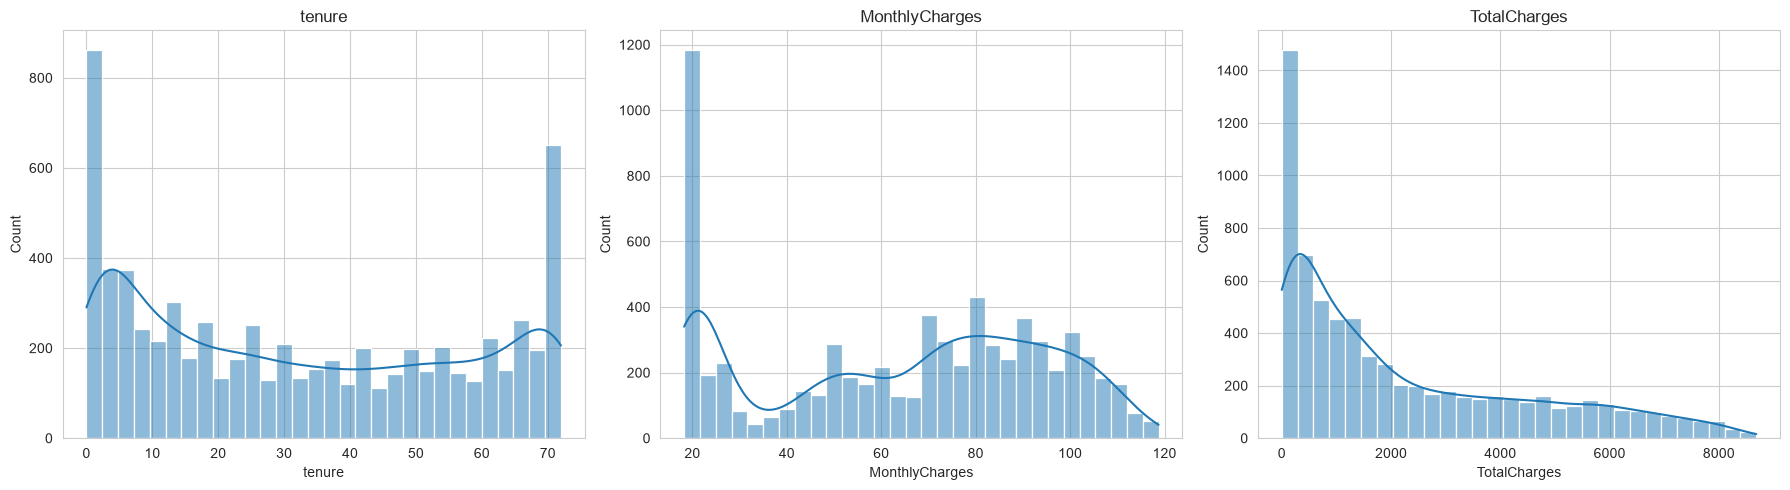

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cols = num_df.columns
for ax, col in zip(axes, cols):
    sns.histplot(data=df, x=col, kde=True, bins=30, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [63]:
print('\nIQR Outlier Report:')
for col in num_df.columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:15s}: bounds=({lower:.1f}, {upper:.1f}) -> outliers = {n_out}')


IQR Outlier Report:
tenure         : bounds=(-60.0, 124.0) -> outliers = 0
MonthlyCharges : bounds=(-46.0, 171.4) -> outliers = 0
TotalCharges   : bounds=(-4683.5, 8868.7) -> outliers = 0


In [64]:
# Final Data Reports 
# ===== Data Quality Report =====
def data_quality_report(data):
    return pd.DataFrame({
        'dtype': data.dtypes.astype(str),
        'non_null': data.count(),
        'missing': data.isnull().sum(),
        'missing_%': (data.isnull().mean()*100).round(2),
        'unique_values': data.nunique(),
    })

print(f'Rows: {df.shape[0]} | Columns: {df.shape[1]} | Duplicates: {df.duplicated().sum()}')
data_quality_report(df)

Rows: 7043 | Columns: 21 | Duplicates: 0


,dtype,non_null,missing,missing_%,unique_values
customerID,str,7043,0,0.0,7043
gender,str,7043,0,0.0,2
SeniorCitizen,str,7043,0,0.0,2
Partner,str,7043,0,0.0,2
Dependents,str,7043,0,0.0,2
tenure,int64,7043,0,0.0,73
PhoneService,str,7043,0,0.0,2
MultipleLines,str,7043,0,0.0,3
InternetService,str,7043,0,0.0,3
OnlineSecurity,str,7043,0,0.0,3


------------------------------
## Exploratory Data Analysis (EDA)
-------------------------------------

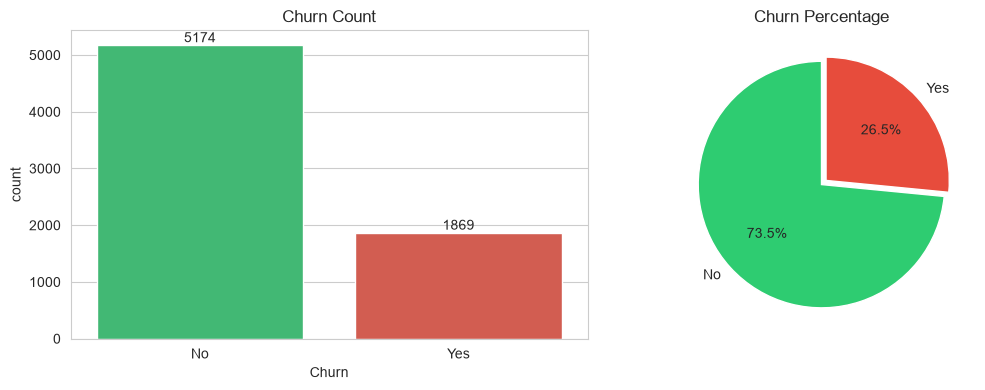

Churn Rate: 26.5%
Imbalance Ratio = 2.8 : 1


In [71]:
# ========== Target Distribution =================
fig, axes = plt.subplots(1,2,figsize=(11,4))
#countplot -exact counts 
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0], legend=False)
axes[0].set_title('Churn Count')
for container in axes[0].containers:
    axes[0].bar_label(container)
# Pie -share at a glace 
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=[0, 0.05])
axes[1].set_title('Churn Percentage')
plt.tight_layout(); plt.show()

print(f'Churn Rate: {churn_pct["Yes"]:.1f}%')
print(f'Imbalance Ratio = {churn_pct["No"]/churn_pct["Yes"]:.1f} : 1')

## Output Interpretation – Critical Findings

* **Churn Rate:** The overall churn rate is approximately **26.5%**, which means **about 1 out of every 4 customers leaves the company**. This is considered a high churn rate for a telecom business and indicates a significant customer retention challenge.

* **Class Imbalance:** The dataset has a class imbalance of approximately **2.8 : 1**, meaning there are about **2.8 non-churn customers for every 1 churn customer**.

### Consequences of Class Imbalance

1. **Biased Model Performance:** Machine learning models may become biased toward predicting the majority class (Non-Churn), resulting in poor detection of churn customers.

2. **Misleading Accuracy:** A model may achieve high accuracy simply by predicting most customers as non-churn, even if it fails to identify customers who actually leave.

3. **Lower Recall for Churn Class:** Without proper handling, the model may miss many actual churn cases (high false negatives), reducing its usefulness for customer retention.

4. **Need for Imbalance Handling:** Techniques such as **SMOTE (oversampling)**, **undersampling**, **class weighting**, or evaluating with metrics like **Precision, Recall, F1-score, and ROC-AUC** should be used instead of relying only on accuracy.

---------------------------------------


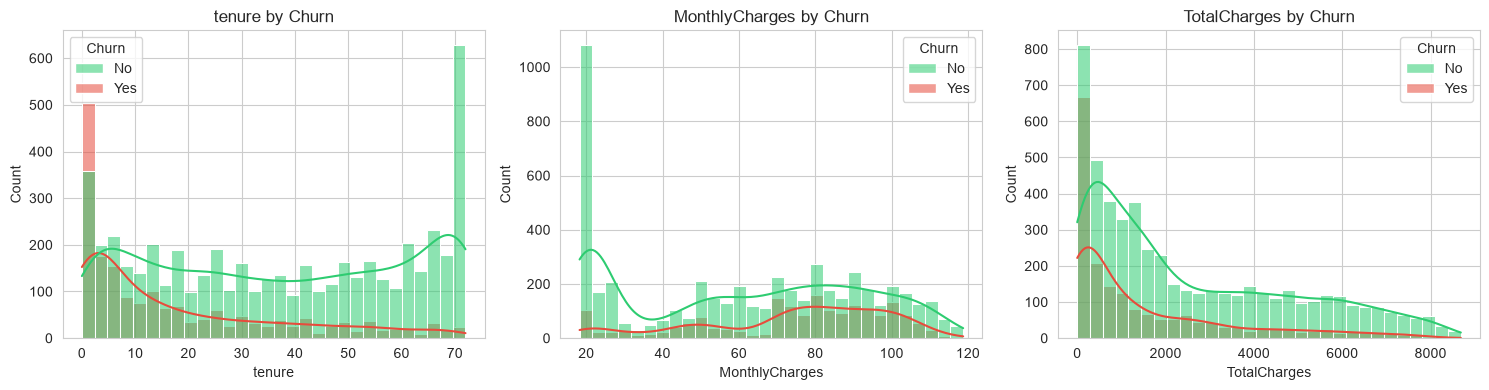

In [72]:
# ===== Numeric Distributions by Churn =====
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True,
                 palette=['#2ecc71', '#e74c3c'], alpha=0.55, ax=ax)
    ax.set_title(f'{col} by Churn')
plt.tight_layout(); plt.show()

## Output Interpretation – Three Business Stories

### 1. Tenure

The churn distribution is concentrated in the **first few months**, indicating that **new customers are the most likely to leave**. Customers with **more than 60 months of tenure** are generally loyal and have a much lower churn rate. The tenure distribution is **bimodal**, meaning there are two large groups: many very new customers and many long-term customers.

### 2. Monthly Charges

Customers with **higher monthly charges** are more likely to churn. The churn distribution shifts toward the **higher price range**, with the **$70–$100** range representing a high-risk or "danger zone" for customer churn.

### 3. Total Charges

The **Total Charges** distribution is **right-skewed**, which is expected because Total Charges increase over time. Since **Total Charges are roughly the product of Monthly Charges and Tenure**, customers with longer tenures naturally accumulate higher total charges, resulting in a long right tail in the distribution.

----------------------------------------------------------

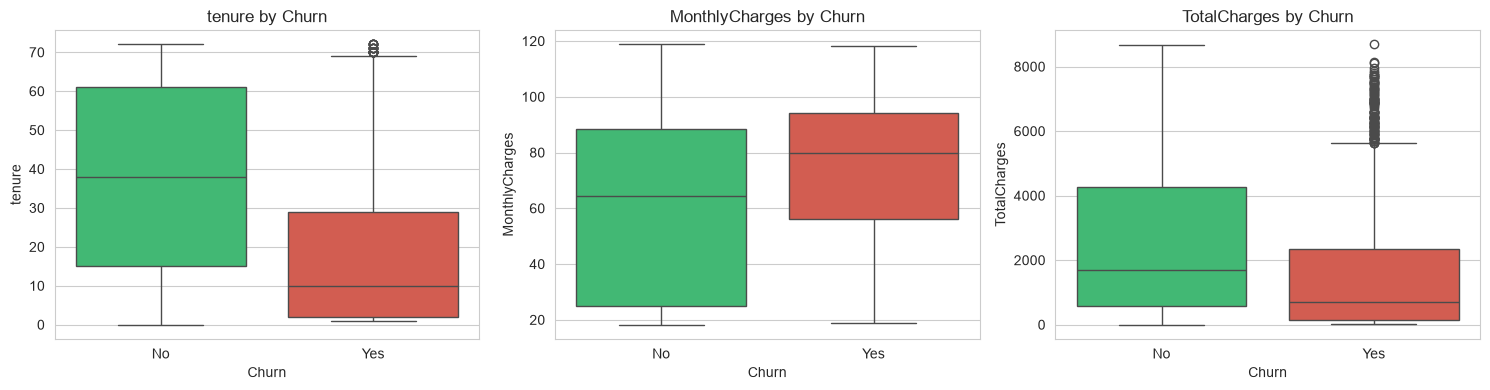



       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0            64.4        1679.5
Yes      10.0            79.6         703.6


In [78]:
#=========== Box plots ===============
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn',
                palette=['#2ecc71', '#e74c3c'], ax=ax, legend=False)
    ax.set_title(f'{col} by Churn')
plt.tight_layout(); plt.show()

print("\n")
print("====================================================")
print(df.groupby('Churn')[num_cols].median().round(1))

## Output Interpretation

* **Tenure:** The median tenure for **Non-Churn** customers is approximately **38 months**, while for **Churn** customers it is only **10 months**. This large difference shows that customers who stay longer are much less likely to churn.

* **Monthly Charges:** The median monthly charge for **Churn** customers is around **$80**, compared to about **$65** for **Non-Churn** customers. This suggests that customers paying higher monthly fees are more likely to leave.

* **Early-Life Churn:** The tenure box for the churn group is concentrated at lower values, indicating that **most customers who churn leave within the early months of their subscription**. This highlights an **early-life churn problem**.

**Business Recommendation:** Implement a strong **customer onboarding and engagement program during the first 6–12 months**. Providing proactive support, personalized communication, and special offers during this period can improve customer satisfaction and reduce churn.



**Box Plot Interpretation by Churn**
* Tenure: Customers who churn have a much lower median tenure than those who stay, indicating that new customers are more likely to leave, while long-term customers are more loyal.
* MonthlyCharges: Churned customers have a higher median monthly charge, suggesting that customers paying higher monthly fees are relatively more likely to churn.
* TotalCharges: Customers who do not churn have higher total charges, mainly because they stay with the company for a longer time. Although most churned customers have lower total charges, a few high-value customers also churn, as shown by the outliers.
-----------------------------------------

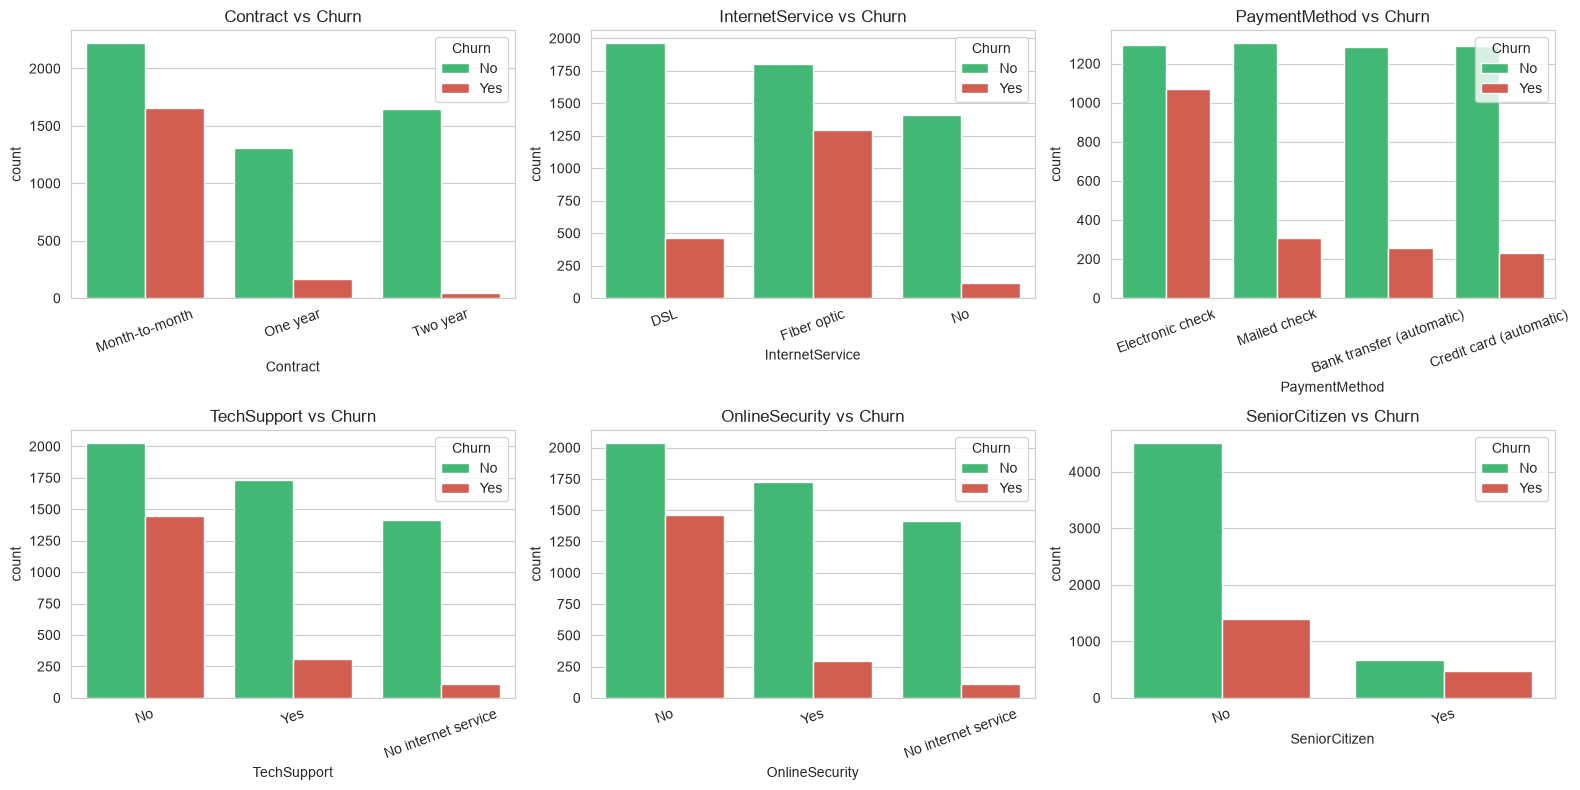

In [79]:
#====================== Countplots ================
key_cats = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_cats):
    sns.countplot(data=df, x=col, hue='Churn',
                  palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_title(f'{col} vs Churn')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

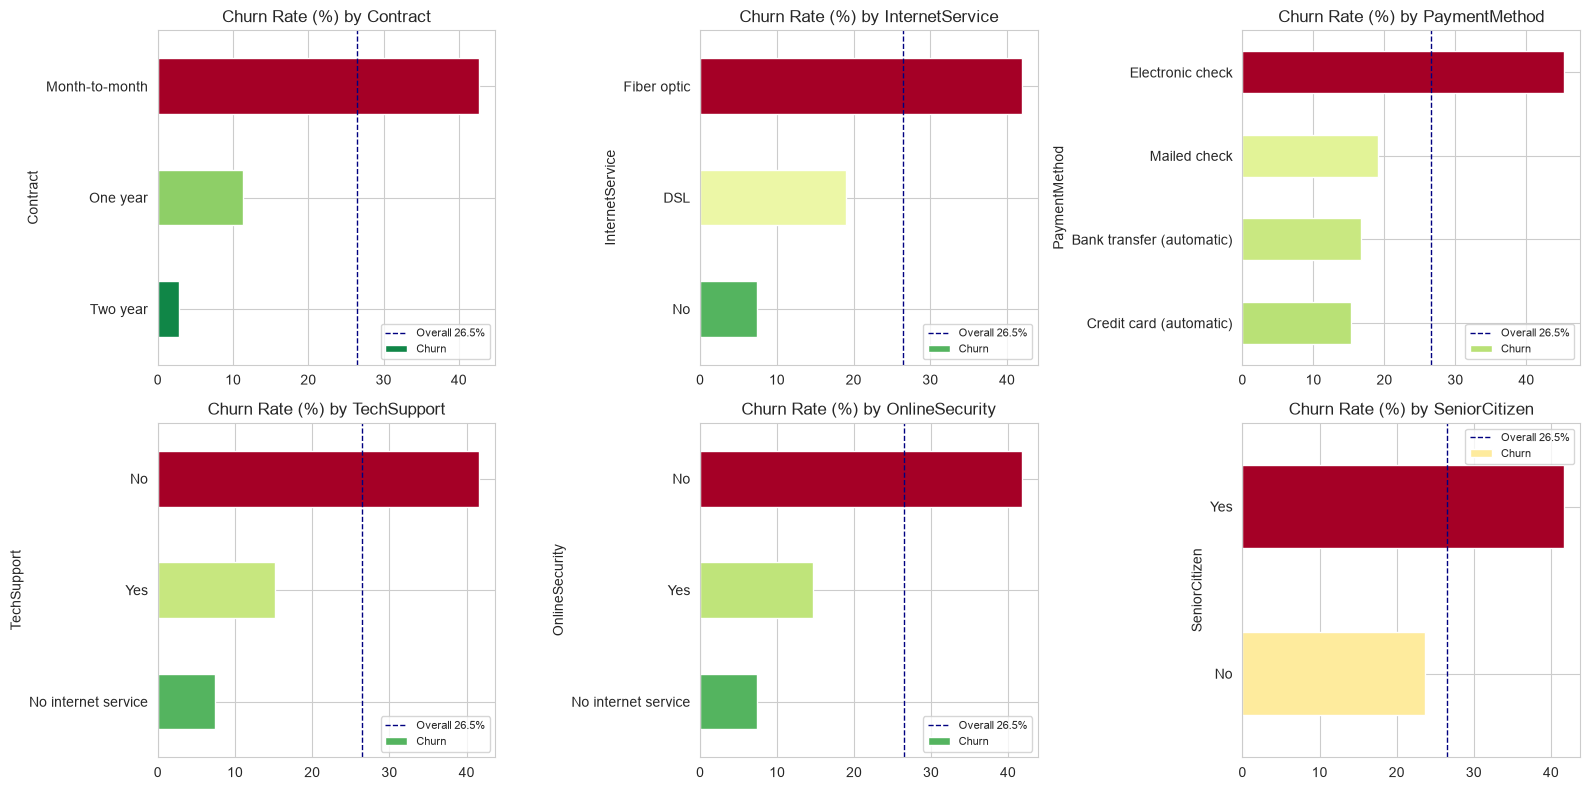

In [83]:
#  Churn RATE per category (more powerful view!) =====
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_cats):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values()
    rate.plot(kind='barh', ax=ax, color=plt.cm.RdYlGn_r(rate / rate.max()))
    ax.set_title(f'Churn Rate (%) by {col}')
    ax.axvline(26.5, color='navy', ls='--', lw=1, label='Overall 26.5%')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Output Interpretation – Key Insights

* **Contract:** Customers with **month-to-month contracts** have a churn rate of about **43%**, while customers with **two-year contracts** have a churn rate of only **3%**. This is the strongest predictor of churn.
  **Recommendation:** Encourage customers to switch to yearly or two-year plans by offering discounts or special benefits.

* **Internet Service:** Customers using **Fiber Optic** service have a much higher churn rate (around **42%**) compared to **DSL** users (around **19%**). This may indicate issues with pricing, service quality, or customer expectations.
  **Recommendation:** Review Fiber Optic pricing, performance, and customer support to improve customer satisfaction.

* **Payment Method:** Customers who pay through **Electronic Check** show the highest churn rate (around **45%**). Customers using **automatic payment methods** are generally more loyal because they do not have to make a payment decision every month.
  **Recommendation:** Offer incentives such as discounts or cashback to encourage customers to switch to AutoPay.

* **Tech Support and Online Security:** Customers who **do not subscribe** to Tech Support or Online Security services have about **twice the churn rate** of those who do. These services increase customer engagement and make customers less likely to leave.
  **Recommendation:** Promote Tech Support and Online Security through bundled plans or free trial offers.

* **Senior Citizens:** Customers who are **Senior Citizens** have a higher churn rate (around **42%**) than other customer groups.
  **Recommendation:** Provide personalized support, easy-to-use services, and special offers tailored for senior customers.
-------------------------------------------------

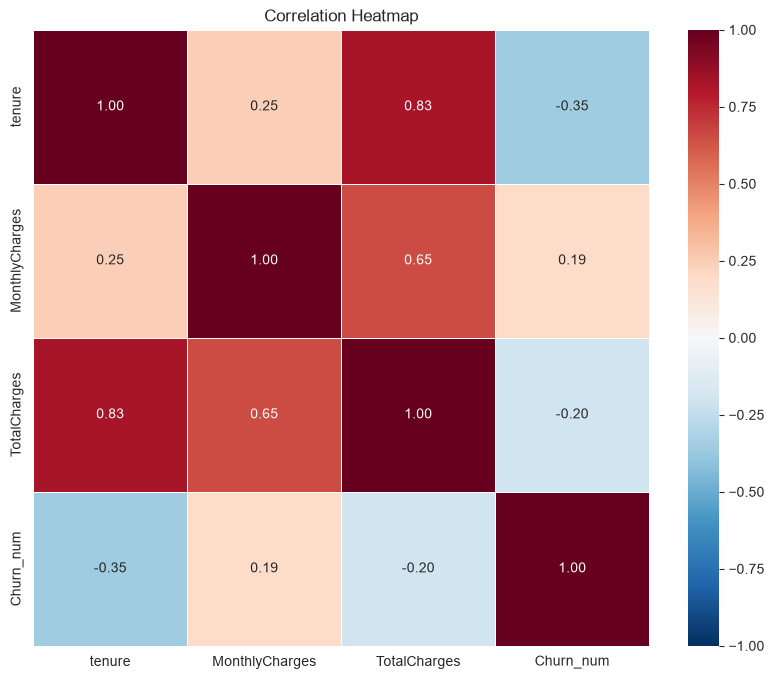

In [87]:
#  Correlation Heatmap =====
df_corr = df[num_cols].copy()
df_corr['Churn_num'] = (df['Churn'] == 'Yes').astype(int)   # only for correlation 

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Output Interpretation

* **Total Charges vs. Tenure:** There is a **strong positive correlation (0.83)** between **Total Charges** and **Tenure**, indicating **multicollinearity**. This is expected because **Total Charges are approximately equal to Tenure × Monthly Charges**. In **linear models**, including both variables may produce unreliable coefficients, while **tree-based models** are generally not affected by this issue.

* **Tenure vs. Churn:** The correlation between **Tenure** and **Churn** is **−0.35**, showing a **negative relationship**. As customer tenure increases, the likelihood of churn decreases. This is consistent with the earlier histogram analysis, where long-term customers were less likely to churn.

* **Monthly Charges vs. Churn:** The correlation between **Monthly Charges** and **Churn** is **+0.19**, indicating a **positive relationship**. Customers with higher monthly bills are more likely to churn than those with lower monthly charges.

  --------------------------------------------------------


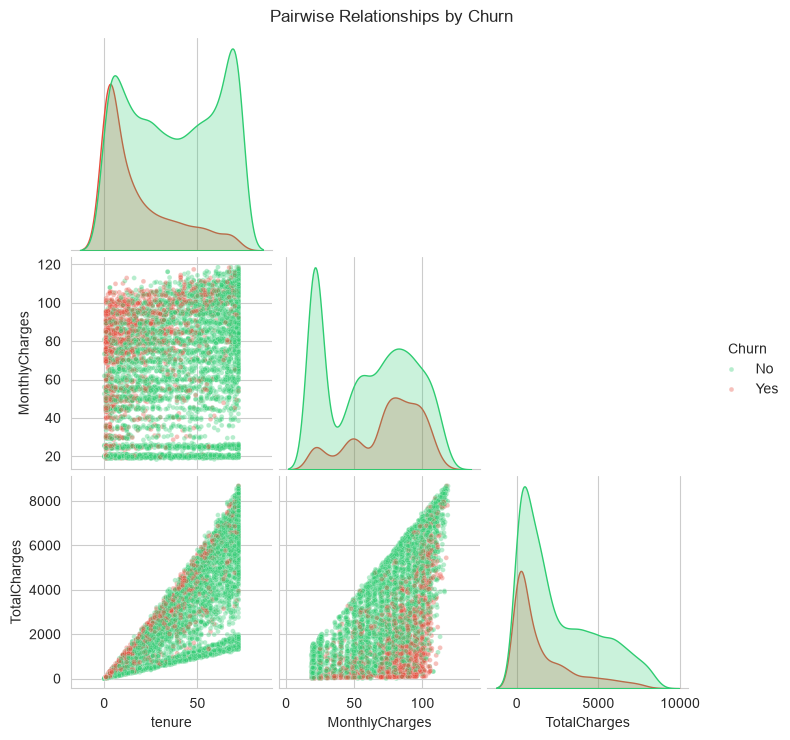

In [88]:
# =====  Pairplot =====
sns.pairplot(df[num_cols + ['Churn']], hue='Churn',
             palette=['#2ecc71', '#e74c3c'],
             plot_kws={'alpha': 0.35, 's': 12}, corner=True, height=2.4)
plt.suptitle('Pairwise Relationships by Churn', y=1.02)
plt.show()

## Output Interpretation

* **Tenure vs. Monthly Charges:** The scatter plot shows a high concentration of **churn customers (red points)** in the **lower-right region**, representing customers with **low tenure and high monthly charges**. This indicates a high-risk **"danger zone"**, where **new customers on expensive plans are the most likely to churn**.

* **Total Charges vs. Tenure:** The scatter plot displays an almost **straight-line relationship** between **Total Charges** and **Tenure**, providing a clear visual confirmation of **multicollinearity**. Since Total Charges increase as customers stay longer, these two variables are highly correlated.
-------------------------------------------------

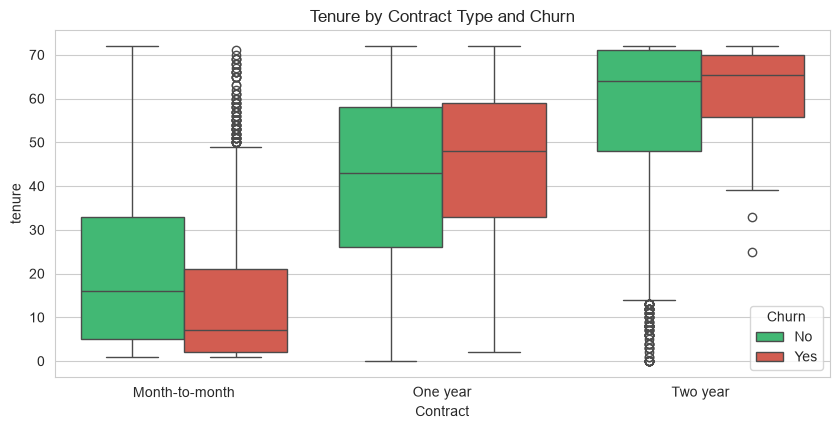

Churn Rate (%) — tenure_group x Contract:
Contract      Month-to-month  One year  Two year
tenure_group                                    
0-12                    51.4      10.5       0.0
13-24                   37.7       8.1       0.0
25-48                   32.9      10.6       2.2
49-72                   26.0      12.9       3.3


In [89]:
# =====  Contract x tenure x Churn =====
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=df, x='Contract', y='tenure', hue='Churn',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure by Contract Type and Churn')
plt.show()

# make Tenure bins  churn rate table
df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                            labels=['0-12', '13-24', '25-48', '49-72'])
pivot = df.pivot_table(index='tenure_group', columns='Contract', values='Churn',
                       aggfunc=lambda s: round((s == 'Yes').mean()*100, 1),
                       observed=True)
print('Churn Rate (%) — tenure_group x Contract:')
print(pivot)

df.drop(columns='tenure_group', inplace=True)   # EDA-only column

## Output Interpretation

* **Month-to-Month Contract (0–12 Months):** Customers with a **month-to-month contract** and **0–12 months of tenure** have a **churn rate of over 50%**. This means that **more than half of the new customers on month-to-month plans leave the company**, making this the highest-risk customer segment.

* **Two-Year Contract (0–12 Months):** In contrast, customers with the **same tenure (0–12 months)** but a **two-year contract** have a **very low churn rate**. This suggests that a long-term contract significantly reduces the risk of churn and effectively offsets the higher churn risk associated with new customers.
------------------------------------------------

# EDA SUMARRY 
--------------------------------------------

## EDA Business Insights Summary

1.  **Highest-Risk Segment:** Month-to-month + Fiber optic +
   Electronic check + tenure < 12 months (churn 50%+)
2.  **Action 1:** नयाँ customers लाई annual-contract discount offer
3.  **Action 2:** Fiber optic को price/quality audit
4.  **Action 3:** Auto-pay switch incentive
5.  **Action 4:** TechSupport/OnlineSecurity bundle promotion

**Modeling Notes:**
- Class imbalance 2.8:1 → class weights + stratified split + Recall/AUC focus
- Multicollinearity: TotalCharges ↔ tenure (0.83)